# Phase 5 — Strategy: One Pair First, Then a Basket of Pairs

**The idea in one line.** We finally place real trades. Phase 4 found pairs of stocks that tend to move together; here we bet that when two such stocks drift apart, they will come back together. We test this only on years the model has never seen (2020 onward), so it is a fair test.

We start with a single pair so the moving parts are easy to follow, then run about ten pairs at once to show that spreading the bets around smooths out the ride.

**Why trade only 2020 onward?** The model learned on 2015–2017, and the pairs were chosen using 2015–2019. Leaving 2020+ completely untouched until now makes this a genuine "would it have worked on brand-new data?" test — and 2020+ includes the COVID crash and the 2022 downturn, so it is a hard one to pass.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shortlist = pd.read_csv('data/model_input/pairs_shortlist.csv')
prices = pd.read_parquet('data/processed/adj_close_clean.parquet')
sectors = pd.read_csv('data/model_input/sectors.csv', index_col=0)['sector']
logp = np.log(prices)
ret = prices.pct_change()
TRADE_START = '2020-01-01'
print(f'Shortlist pairs: {len(shortlist)}')
print(f'Trading window: {prices.loc[TRADE_START:].index.min().date()} -> {prices.index.max().date()}  ({len(prices.loc[TRADE_START:])} days)')

Shortlist pairs: 112
Trading window: 2020-01-02 -> 2026-04-17  (1581 days)


## How one pair is traded

**The "gap".** For two stocks A and B, we track the gap between them — a weighted difference of their prices. The weight (the *hedge ratio* from Phase 4) is set so we buy one side and sell the other in balanced amounts. That balance is what lets the trade shrug off the overall market: if everything rises together, both sides rise and the gap barely moves, so our profit comes only from the two stocks drifting apart and then closing back up — not from guessing the market's direction. (Traders call this "market-neutral".)

**When we buy and sell.** Each day we ask how unusual today's gap is versus its recent normal — loosely, "how many steps from average". When the gap stretches unusually wide (about 2 steps), we bet it will close and open the trade. When it comes back near normal (half a step), we close and take the result.

**Why this quietly adjusts to calm vs. wild markets.** "How unusual" is judged against the gap's *recent* size. In calm spells the normal gap is small, so even a small move already looks unusual; in stormy spells the normal gap is large, so we wait for a bigger move before acting. One simple rule therefore tightens up when markets are quiet and loosens when they are rough — with no extra dials to set. (This is the "adaptive volatility-based thresholds" the project promised.)

**How the money is counted.** On any day we hold a position, the pair gains or loses based on how A moved versus B, scaled to "profit per pound put to work". We always act on *yesterday's* signal, never today's, so we never accidentally use information we would not have had at the time.

In [11]:
def zscore(s, w=60):
    return (s - s.rolling(w).mean()) / s.rolling(w).std()

def positions(z, entry=2.0, exit_=0.5):
    pos, state = np.zeros(len(z)), 0
    for i, zi in enumerate(z.to_numpy()):
        if np.isnan(zi):
            state = 0
        elif state == 0:
            state = -1 if zi > entry else (1 if zi < -entry else 0)
        elif state == 1 and zi >= -exit_:
            state = 0
        elif state == -1 and zi <= exit_:
            state = 0
        pos[i] = state
    return pd.Series(pos, index=z.index)

def pair_pnl(a, b, hedge):
    z = zscore(logp[a] - hedge * logp[b])
    pos = positions(z)
    leg = (ret[a] - hedge * ret[b]).fillna(0)
    pr = pos.shift(1).fillna(0) * leg / (1 + abs(hedge))
    return pr.loc[TRADE_START:], pos.loc[TRADE_START:], z.loc[TRADE_START:]

def perf(pr):
    eq = (1 + pr).cumprod()
    cum = eq.iloc[-1] - 1
    ann = (1 + cum) ** (252 / len(pr)) - 1
    sharpe = pr.mean() / pr.std() * np.sqrt(252) if pr.std() > 0 else np.nan
    mdd = (eq / eq.cummax() - 1).min()
    return {'cum_return': cum, 'ann_return': ann, 'sharpe': sharpe, 'max_drawdown': mdd}, eq

def trade_stats(pos, pr):
    # a day's return comes from yesterday's position, so we segment on the
    # effective (shifted) position to line each trade up with the P&L it earned
    eff = pos.shift(1).fillna(0)
    runs, cur = [], None
    for t, p in eff.items():
        if p != 0 and cur is None:
            cur = [t, t]
        elif p != 0:
            cur[1] = t
        elif cur is not None:
            runs.append(cur); cur = None
    if cur is not None:
        runs.append(cur)
    rets = np.array([(1 + pr.loc[s:e]).prod() - 1 for s, e in runs])
    durs = np.array([pr.loc[s:e].shape[0] for s, e in runs])
    win = float((rets > 0).mean()) if len(rets) else np.nan
    pf = float(rets[rets > 0].sum() / -rets[rets < 0].sum()) if (rets < 0).any() else np.nan
    return {'n_trades': len(runs), 'avg_duration': float(durs.mean()) if len(durs) else np.nan,
            'win_rate': win, 'profit_factor': pf}

### What the scorecard numbers mean

The next cell prints a little report card for the pair. In plain terms:
- **cum_return** — total growth over the whole period (0.43 means +43%).
- **ann_return** — that same growth squeezed into a per-year figure.
- **sharpe** — how much reward you got for the bumpiness you put up with; bigger is better, and above about 1 is considered good. It is the number people quote most.
- **max_drawdown** — the worst fall from a high point to a later low along the way (−0.13 means at the worst moment you were down 13%).
- **n_trades / avg_duration** — how many complete buy-then-close trades there were, and how many days each was held on average.
- **win_rate** — the share of trades that ended in profit.
- **profit_factor** — pounds won for every pound lost; above 1 means you came out ahead.

In [12]:
p0 = shortlist.iloc[0]
pr, pos, z = pair_pnl(p0.asset1, p0.asset2, p0.hedge_ratio)
m, eq = perf(pr)
res_single = pd.Series({**m, **trade_stats(pos, pr)})
print(f'Single pair: {p0.asset1}-{p0.asset2}  (hedge {p0.hedge_ratio:.3f}, half-life {p0.half_life:.0f}d)')
print(res_single.round(4).to_string())

Single pair: NTRS-RF  (hedge 0.618, half-life 19d)
cum_return        0.4281
ann_return        0.0584
sharpe            0.5792
max_drawdown     -0.1274
n_trades         32.0000
avg_duration     21.6875
win_rate          0.6875
profit_factor     2.5215


### How to read the two charts below

- **Top — the gap, day by day.** The wavy line shows how unusual the gap between the two stocks is each day. The red dashed lines (about 2 "steps" out) are where we open a trade; the grey lines (half a step) are where we close it. A good pair keeps wandering above and below the middle and crossing those lines — every crossing is a chance to trade.
- **Bottom — the running pot.** This is £1 growing or shrinking as we trade this single pair from 2020 onward. Rising and to the right is good; the dips are the losing stretches.

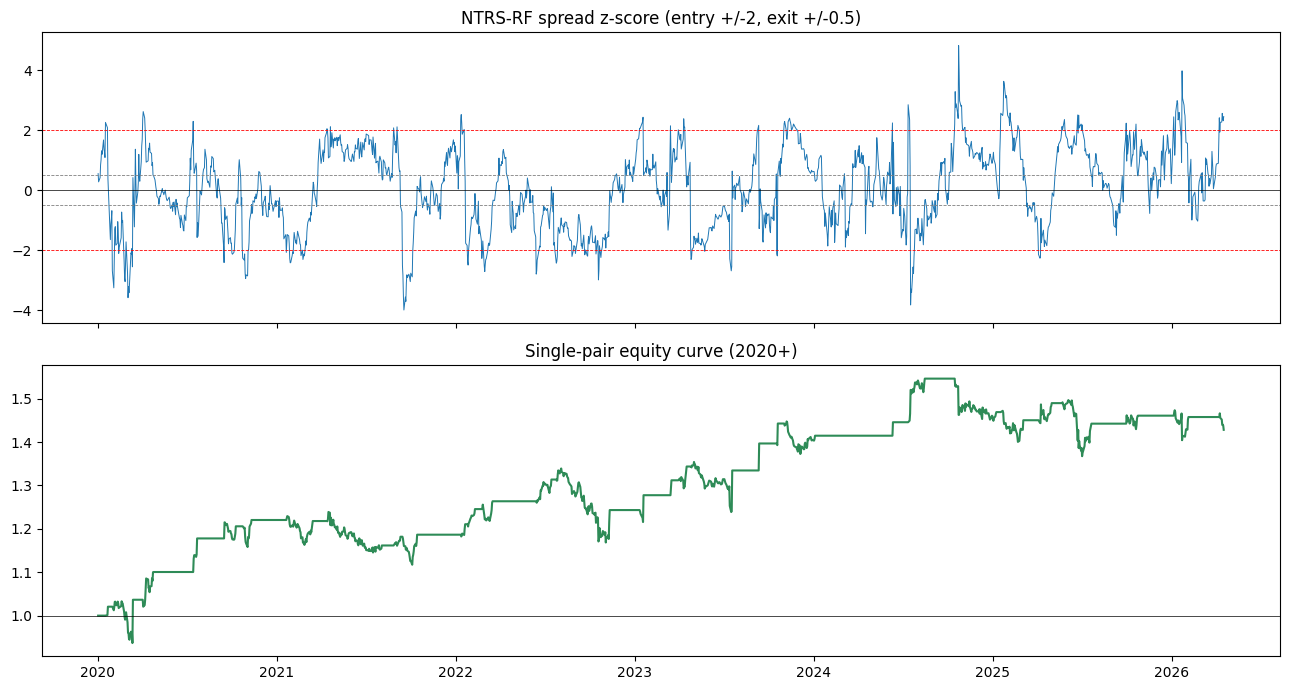

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(z.index, z.values, lw=0.7)
for lev, col in [(2, 'r'), (-2, 'r'), (0.5, 'grey'), (-0.5, 'grey')]:
    ax[0].axhline(lev, color=col, ls='--', lw=0.6)
ax[0].axhline(0, color='k', lw=0.5)
ax[0].set_title(f'{p0.asset1}-{p0.asset2} spread z-score (entry +/-2, exit +/-0.5)')
ax[1].plot(eq.index, eq.values, color='seagreen'); ax[1].axhline(1, color='k', lw=0.5)
ax[1].set_title('Single-pair equity curve (2020+)')
plt.tight_layout(); plt.show()

## Trading a basket of pairs

Now we run several pairs at once. Going down Phase 4's list from strongest to weakest, we take a pair only if **neither of its two stocks is already in use** by a pair we have already picked. That stops any one company from quietly driving several trades, and naturally mixes in banks, utilities, property firms and so on. Each pair gets an equal share of the money.

**Why bother.** A single pair can have a rough patch on its own. Ten largely unrelated pairs rarely all struggle at the same time, so the combined pot rises and falls more gently than any one pair — the old "don't put all your eggs in one basket".

In [14]:
N = 10
used, picked = set(), []
for r in shortlist.itertuples():
    if r.asset1 in used or r.asset2 in used:
        continue
    picked.append((r.asset1, r.asset2, r.hedge_ratio)); used.update([r.asset1, r.asset2])
    if len(picked) == N:
        break
prs = {f'{a}-{b}': pair_pnl(a, b, h)[0] for a, b, h in picked}
prs = pd.DataFrame(prs)
port = prs.mean(axis=1)
print(f'Selected {len(picked)} diversified pairs:')
for a, b, h in picked:
    print(f'  {a}-{b}  ({sectors.get(a, "?")[:12]})')

Selected 10 diversified pairs:
  NTRS-RF  (Financials)
  COF-HBAN  (Financials)
  MTB-RJF  (Financials)
  MET-C  (Financials)
  BK-SCHW  (Unknown)
  AWK-CMS  (Utilities)
  KEY-MS  (Financials)
  SRE-ETR  (Utilities)
  AEP-WEC  (Utilities)
  TFC-BAC  (Financials)


In [15]:
mp, eqp = perf(port)
div_ratio = prs.std().mean() / port.std()
res_port = pd.Series({**mp, 'diversification_ratio': div_ratio})
print('Portfolio (equal-weight, 2020+):')
print(res_port.round(4).to_string())

Portfolio (equal-weight, 2020+):
cum_return               0.1231
ann_return               0.0187
sharpe                   0.4420
max_drawdown            -0.0798
diversification_ratio    2.2943


### How to read the three charts below

- **Left — running pot.** The basket of pairs (blue) next to the single pair (green). We are hoping the blue line is steadier — fewer sharp dips — even if it does not climb quite as high.
- **Middle — the dips.** How far the basket has fallen below its best level so far at each moment; think of it as "how uncomfortable was it to be holding". Shallower is better.
- **Right — who pulled their weight.** Each pair's total profit over the period, so we can see whether the gains were spread around or came from just one or two pairs.

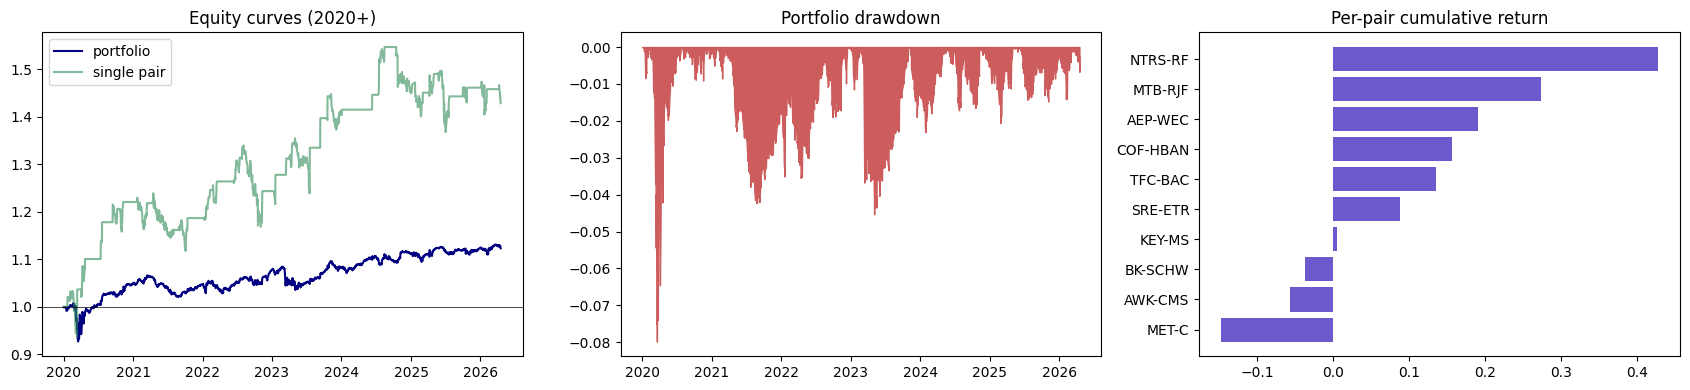

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(eqp.index, eqp.values, color='navy', label='portfolio')
ax[0].plot(eq.index, eq.values, color='seagreen', alpha=0.6, label='single pair')
ax[0].axhline(1, color='k', lw=0.5); ax[0].legend(); ax[0].set_title('Equity curves (2020+)')
dd = eqp / eqp.cummax() - 1
ax[1].fill_between(dd.index, dd.values, color='indianred'); ax[1].set_title('Portfolio drawdown')
contrib = prs.apply(lambda c: (1 + c).prod() - 1).sort_values()
ax[2].barh(contrib.index, contrib.values, color='slateblue'); ax[2].set_title('Per-pair cumulative return')
plt.tight_layout(); plt.show()

## Is the basket really balanced and market-proof?

Three honest checks:
1. **Reused stocks** — does any company show up in more than one pair? Our picking rule should give zero.
2. **Industry mix** — how the stocks spread across industries.
3. **Market sensitivity** — if the whole market moves 1% on a day, how much does our basket move? We want this near zero, which would confirm the basket makes money from pairs closing back up, not from riding the market up or down. (The technical name for this sensitivity is the portfolio's *beta*.)

**How to read the scatter below:** each dot is one day — the market's move that day (left–right) against our basket's move (up–down). If the red line through the dots is nearly flat, the basket barely reacts to the market. A flat line is exactly what we want.

Stocks used in more than one pair: 0  (diversified selection -> expect 0)
Sector spread of the legs:
sector
Financials    13
Utilities      6
Unknown        1
Portfolio beta to equal-weight market: +0.0876  (target ~ 0)


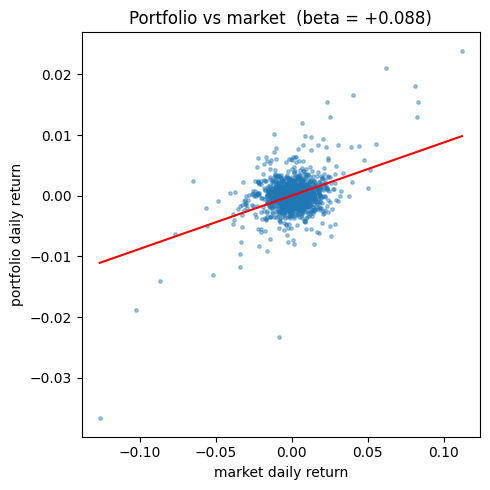

In [17]:
legs = [x for a, b, _ in picked for x in (a, b)]
shared = pd.Series(legs).value_counts()
mkt = ret.mean(axis=1).loc[TRADE_START:]
common = port.index.intersection(mkt.index)
beta = np.polyfit(mkt.loc[common].values, port.loc[common].values, 1)[0]
print(f'Stocks used in more than one pair: {int((shared > 1).sum())}  (diversified selection -> expect 0)')
print('Sector spread of the legs:')
print(sectors.reindex(legs).value_counts().to_string())
print(f'Portfolio beta to equal-weight market: {beta:+.4f}  (target ~ 0)')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(mkt.loc[common], port.loc[common], s=6, alpha=0.4)
xs = np.array([mkt.min(), mkt.max()])
ax.plot(xs, beta * xs, color='r')
ax.set_xlabel('market daily return'); ax.set_ylabel('portfolio daily return')
ax.set_title(f'Portfolio vs market  (beta = {beta:+.3f})')
plt.tight_layout(); plt.show()

## Save the results

- **portfolio_pairs.csv** — the pairs we actually traded, with their balancing weights.
- **strategy_metrics.csv** — the single-pair and basket report cards, side by side.

These are the baseline numbers that the later phases — the rolling-window test (Phase 6) and the comparison against simpler methods (Phase 9) — will be measured against.

In [18]:
pd.DataFrame([{'asset1': a, 'asset2': b, 'hedge_ratio': h} for a, b, h in picked]).to_csv(
    'data/model_input/portfolio_pairs.csv', index=False)
pd.concat([res_single.rename('single_pair'), res_port.rename('portfolio')], axis=1).to_csv(
    'data/model_input/strategy_metrics.csv')
print('Saved portfolio_pairs.csv and strategy_metrics.csv')
print(f'Single-pair Sharpe {res_single["sharpe"]:.2f} | Portfolio Sharpe {res_port["sharpe"]:.2f} | beta {beta:+.3f}')

Saved portfolio_pairs.csv and strategy_metrics.csv
Single-pair Sharpe 0.58 | Portfolio Sharpe 0.44 | beta +0.088
